
Purpose: quick exploratory data analysis of the UCI Air Quality dataset - load, clean, derive time features, and visualize key pollutant and weather patterns to inform later modeling.

Install dataset helper (run once if not already installed).

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Load libraries used throughout the EDA.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, mannwhitneyu, ks_2samp, pearsonr
from ucimlrepo import fetch_ucirepo

Fetch the UCI Air Quality dataset (id=360) and show its metadata and variables.

In [3]:
air_quality = fetch_ucirepo(id=360)
X = air_quality.data.features
y = air_quality.data.targets

print(air_quality.metadata)
print(air_quality.variables)

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

Combine predictors and targets into a single DataFrame.

In [4]:
df = pd.concat([X, y], axis=1)

Replace sentinel value -200 with NaN to mark missing readings and count them.

In [5]:
df.replace(-200, np.nan, inplace=True)
print('Missing values after replacing -200 with NaN:')
print(df.isnull().sum())

Missing values after replacing -200 with NaN:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


Build a datetime index from Date and Time, set it as index, and drop raw columns.

In [6]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'].str.replace('.', ':'),
    format='%m/%d/%Y %H:%M:%S'
)
df.set_index('datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

Add calendar features (hour, weekday, month) for grouping analyses.

In [7]:
df['hour'] = df.index.hour
df['weekday'] = df.index.weekday
df['month'] = df.index.month

Preview the cleaned data and its shape.

In [8]:
display(df.head())
print(df.shape)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour,weekday,month
datetime,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,2,3
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,2,3
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,2,3
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,2,3
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,2,3


(9357, 16)


## Analyze time patterns and seasonal effects

Visualize the data over time to identify trends and seasonality.

Define core pollutant and meteorological features used in subsequent plots.

In [9]:
features = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NMHC(GT)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Plot time series for each feature to inspect trends and seasonality.

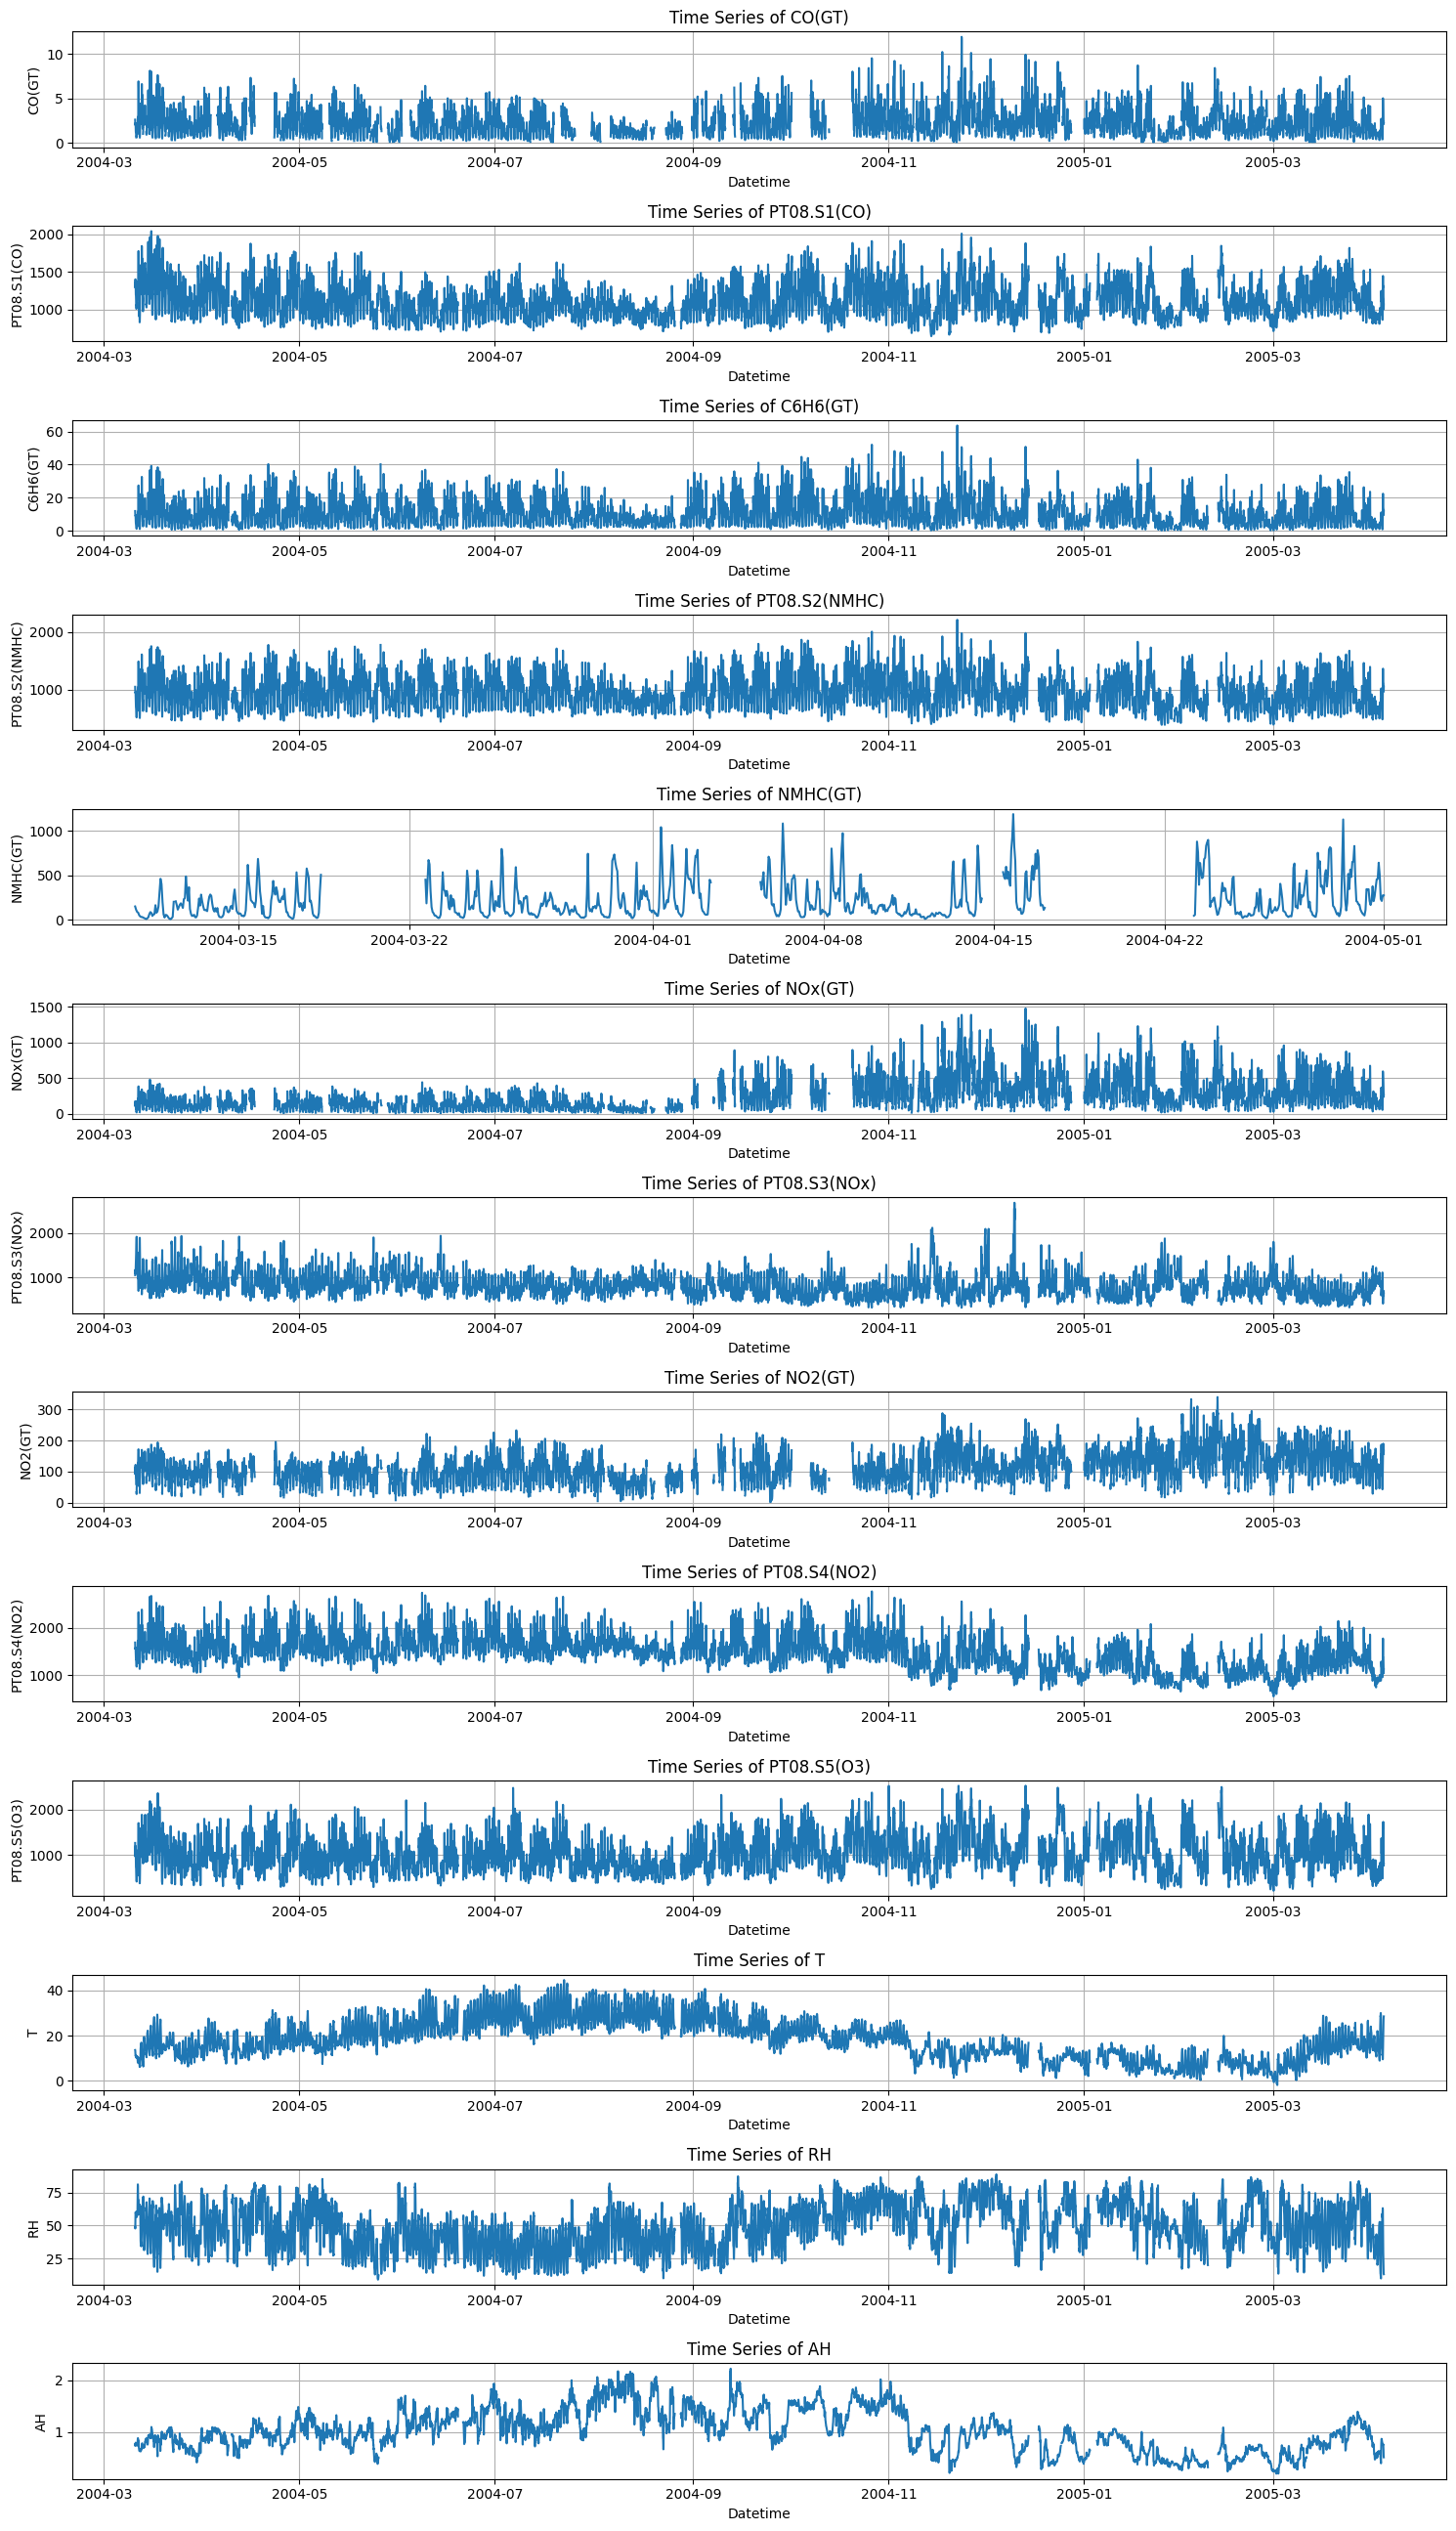

In [10]:
plt.figure(figsize=(15, 26))
for i, feature in enumerate(features):
    plt.subplot(len(features), 1, i + 1)
    plt.plot(df.index, df[feature])
    plt.title(f'Time Series of {feature}')
    plt.xlabel('Datetime')
    plt.ylabel(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()

## Histograms for Weekday vs. Weekend

Compare distribution shifts between weekdays and weekends.

Split data into weekdays vs. weekends for distribution comparisons.

In [11]:
df_weekdays = df[df['weekday'].isin([0, 1, 2, 3, 4])]
df_weekends = df[df['weekday'].isin([5, 6])]

print('Shape of df_weekdays:', df_weekdays.shape)
print('Shape of df_weekends:', df_weekends.shape)

Shape of df_weekdays: (6669, 16)
Shape of df_weekends: (2688, 16)


Plot distributions for weekdays vs. weekends with median and peak markers.

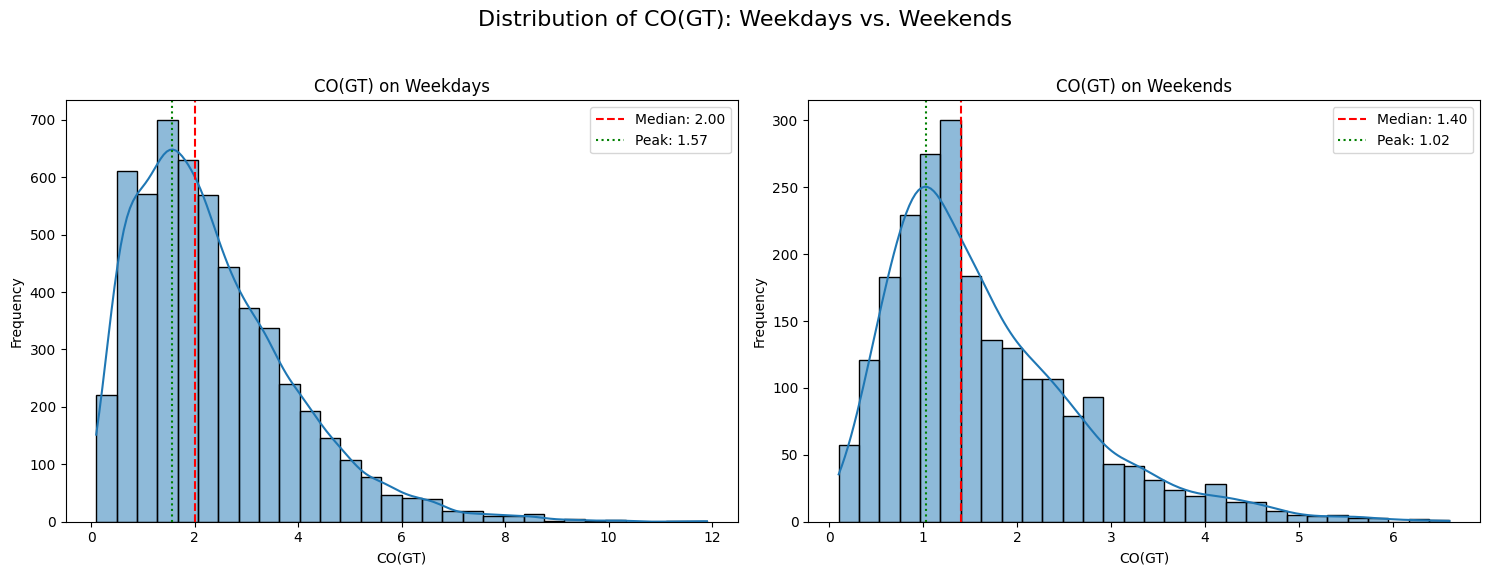

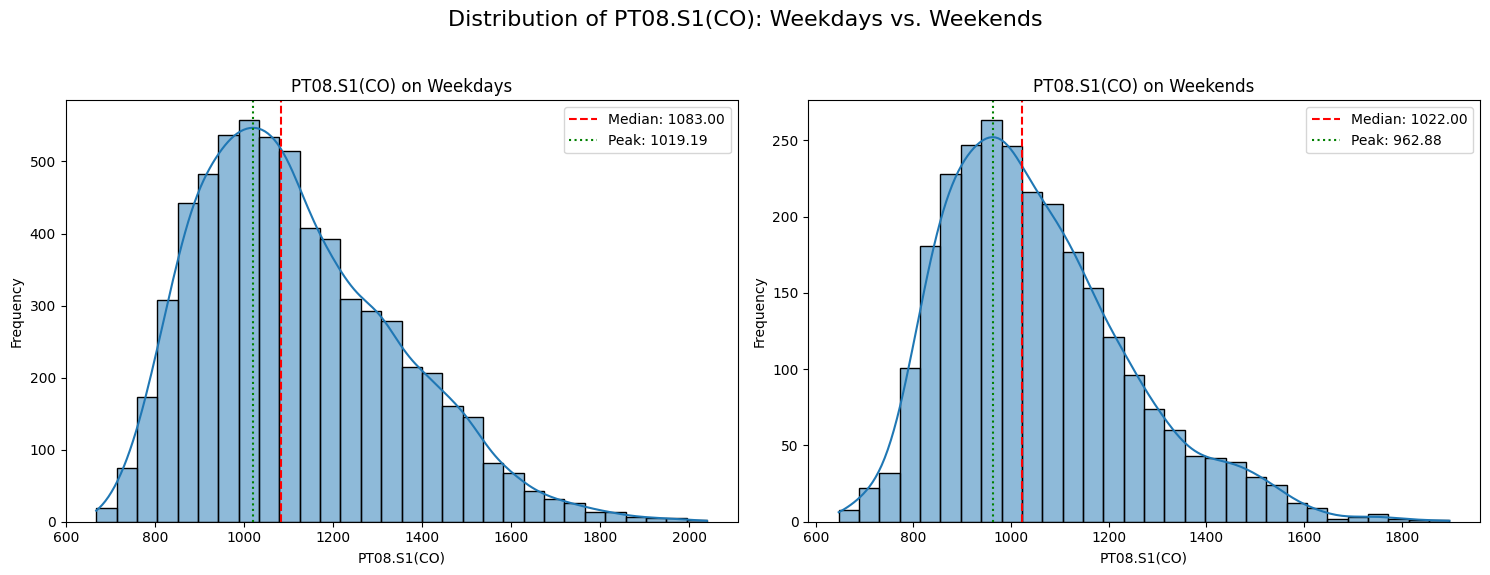

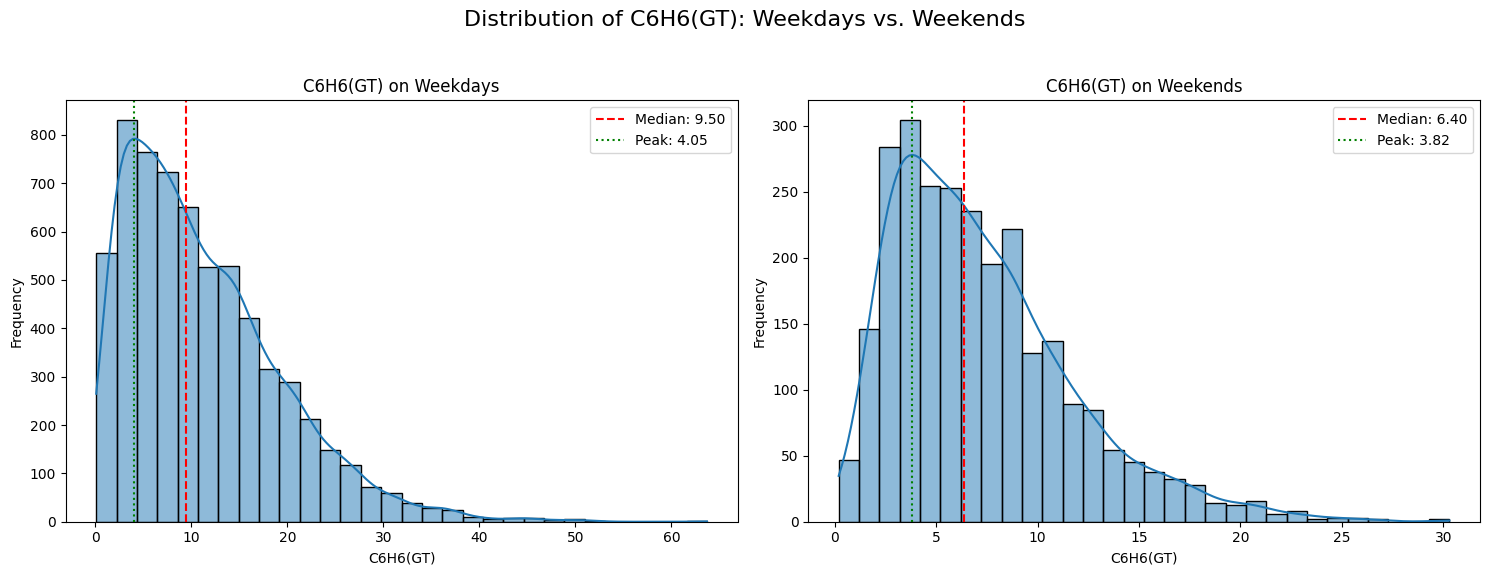

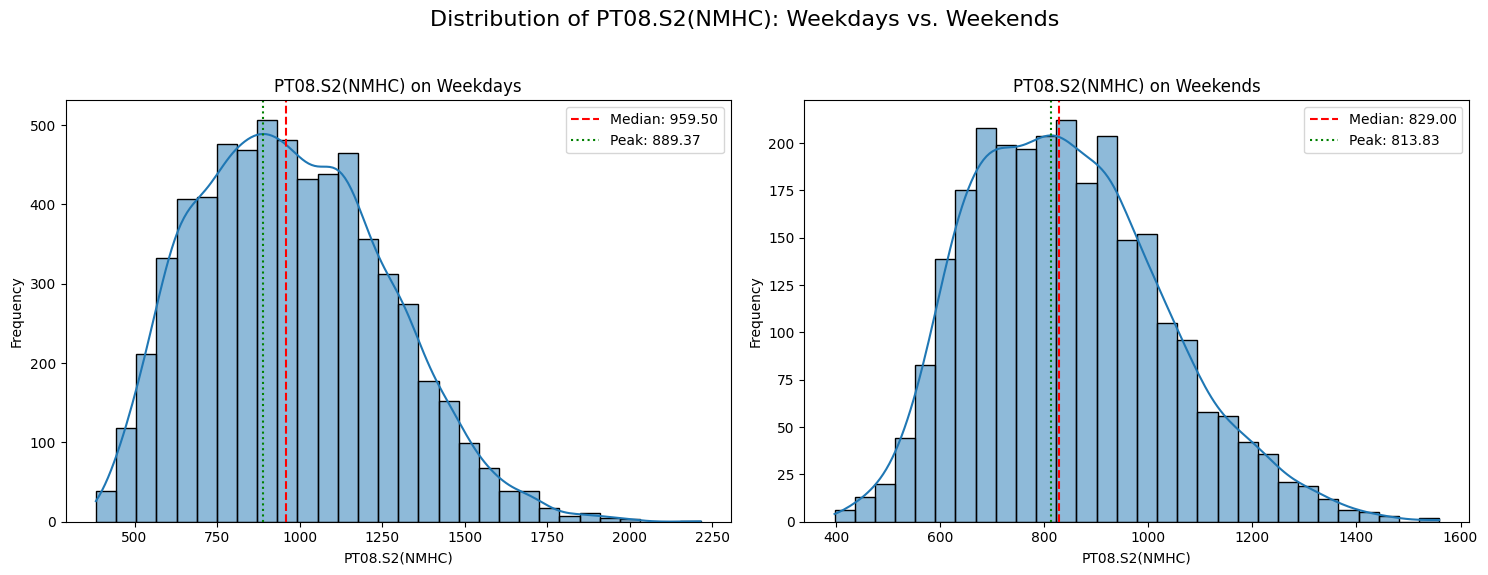

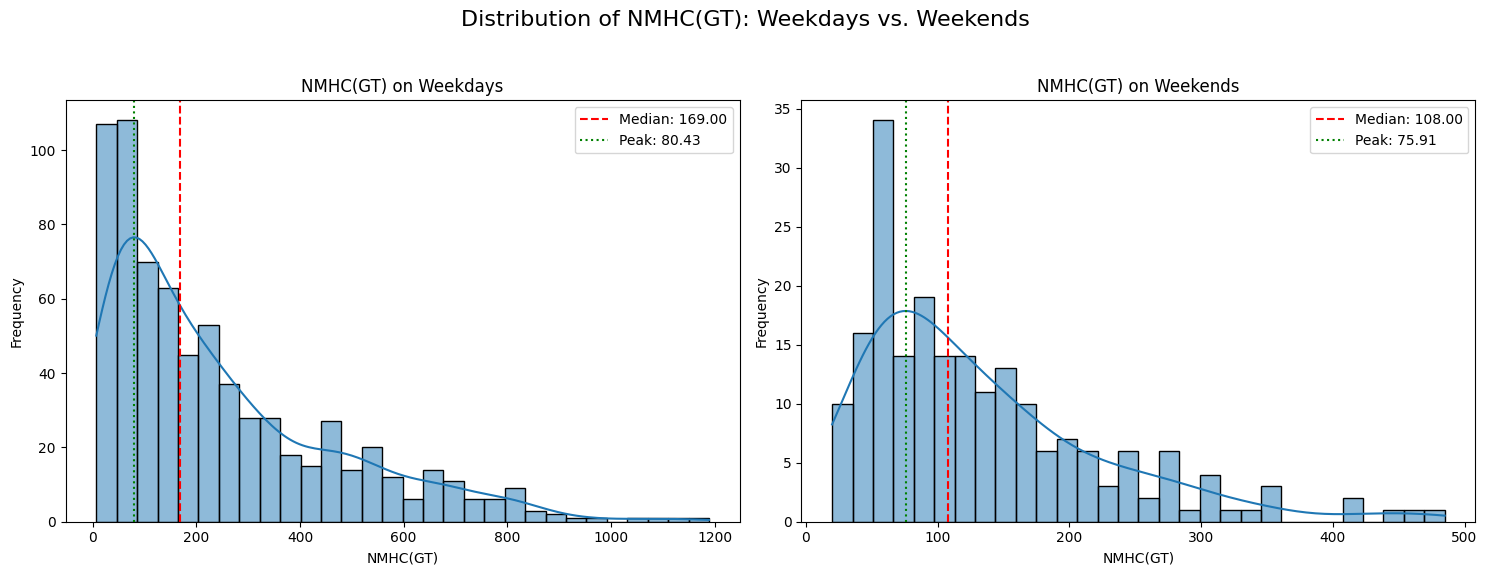

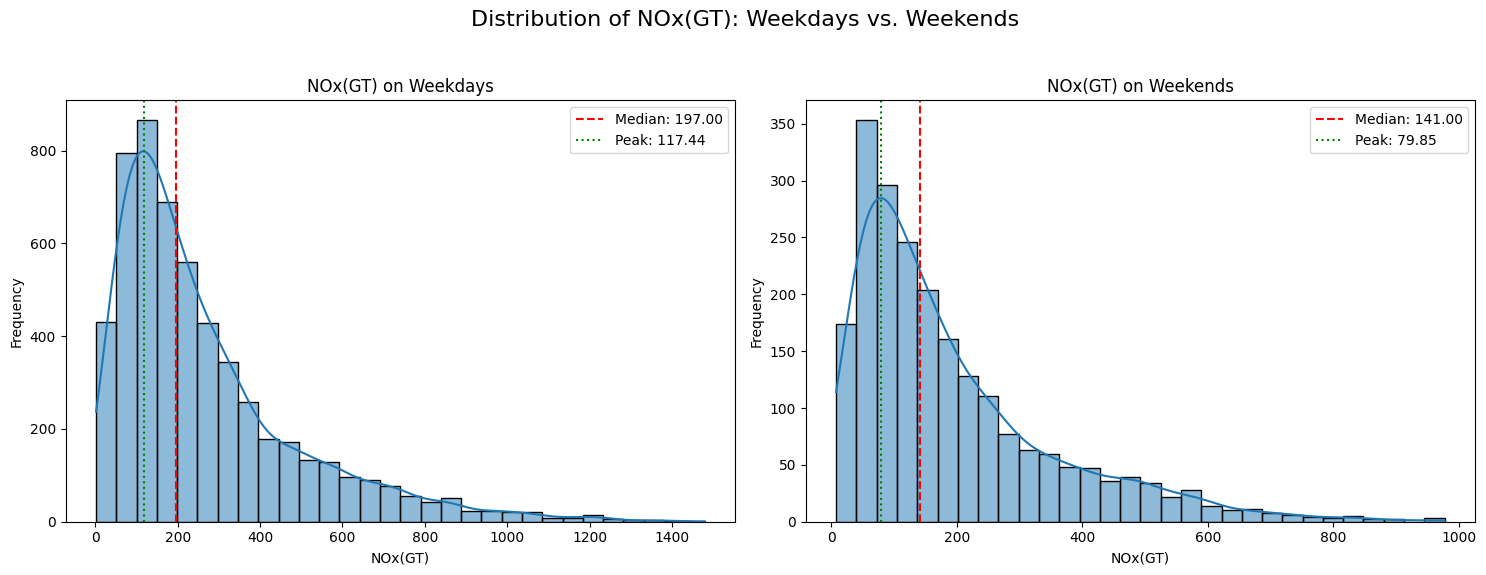

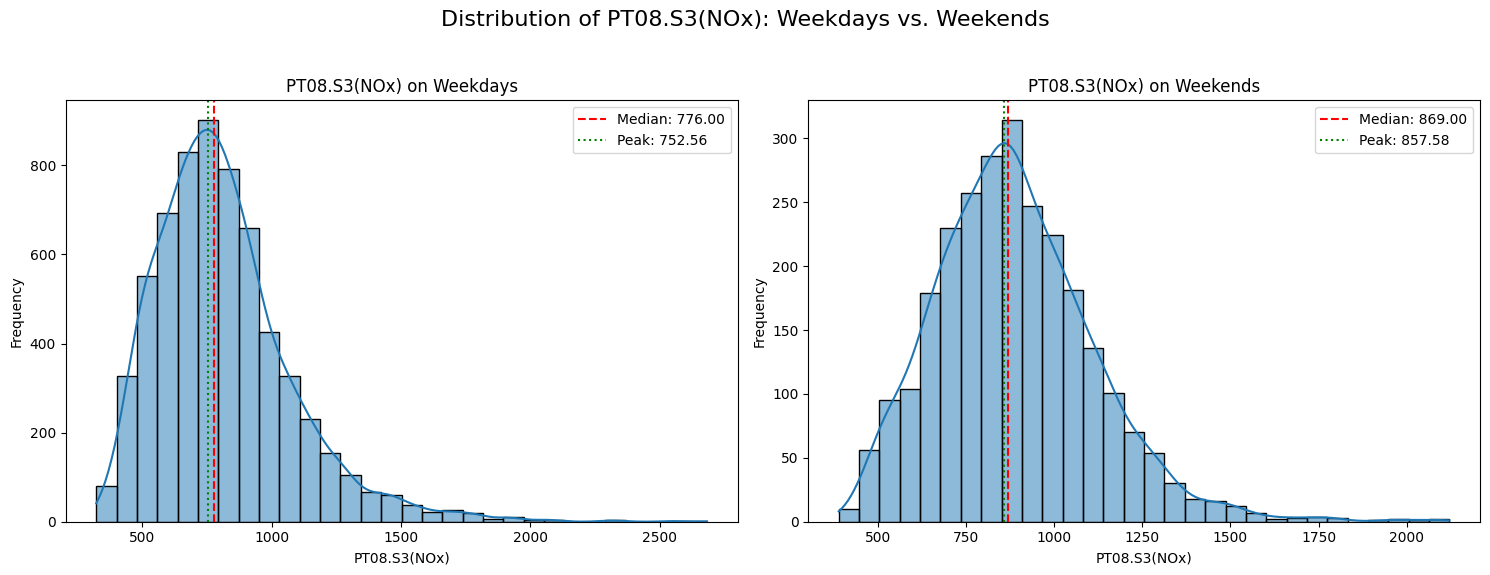

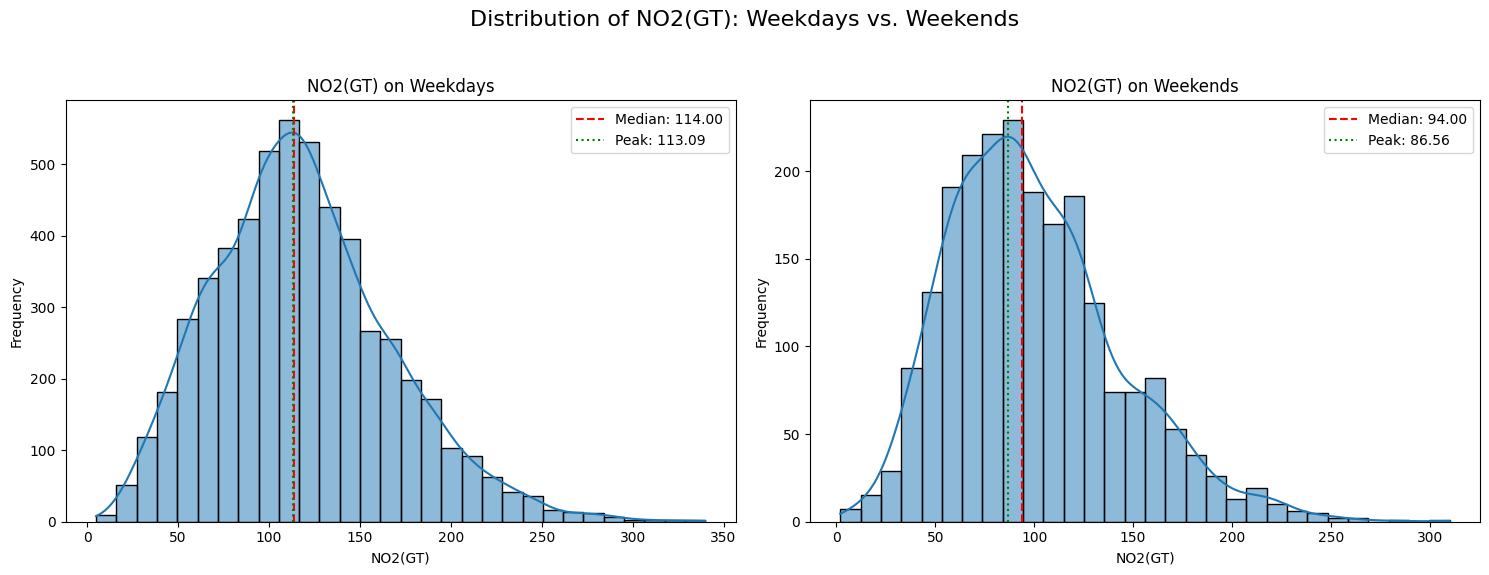

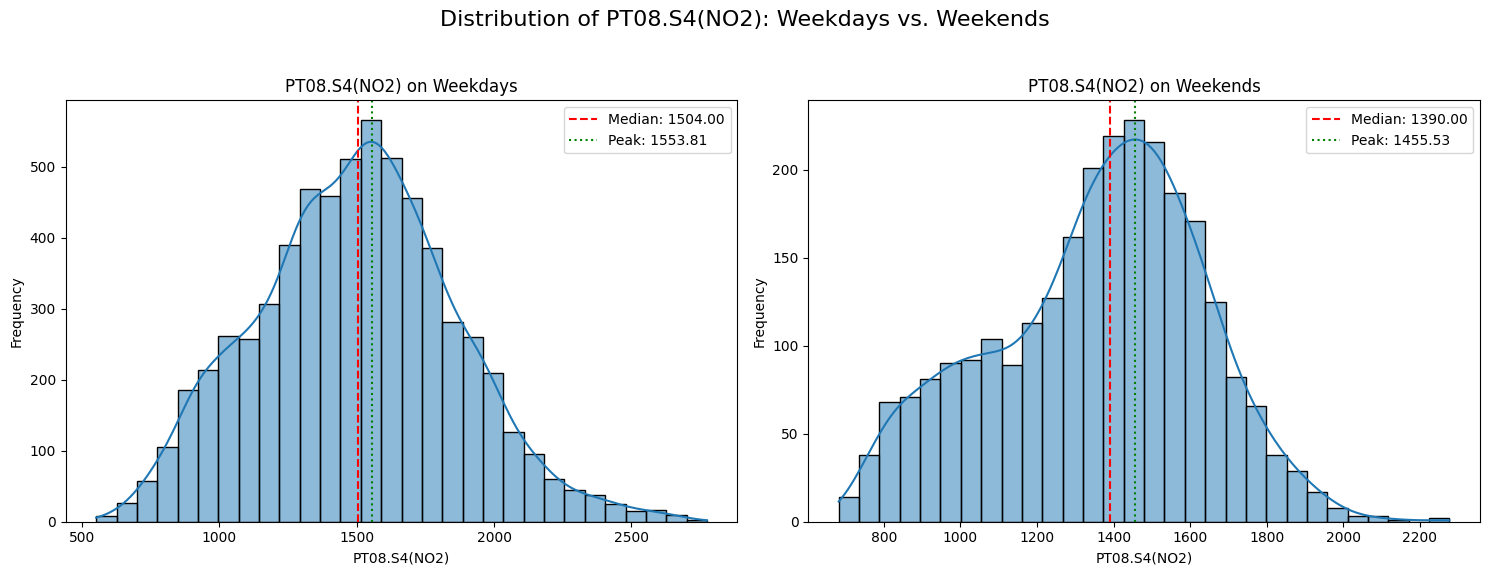

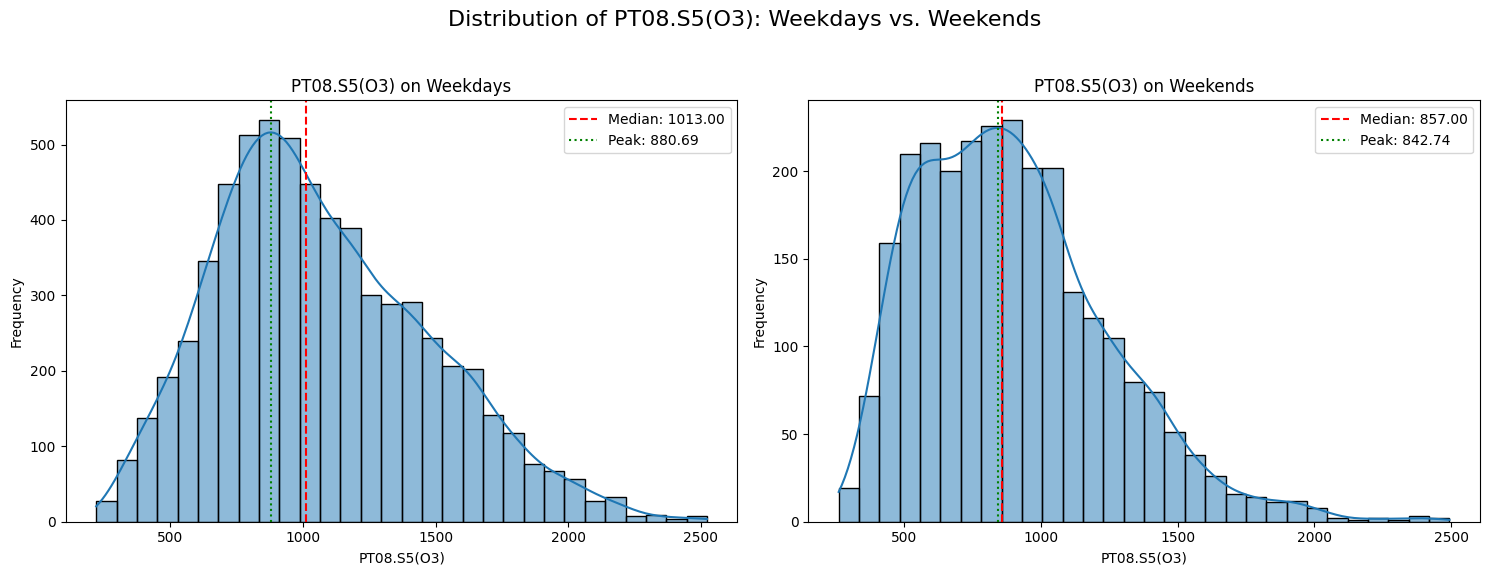

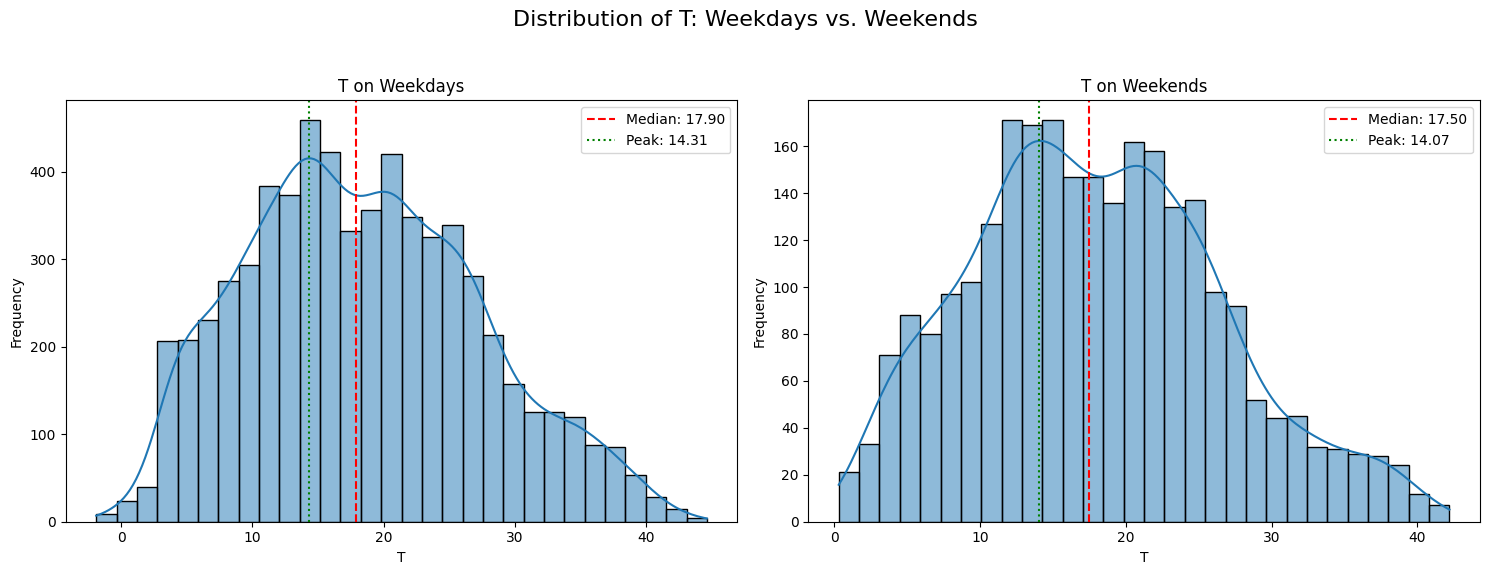

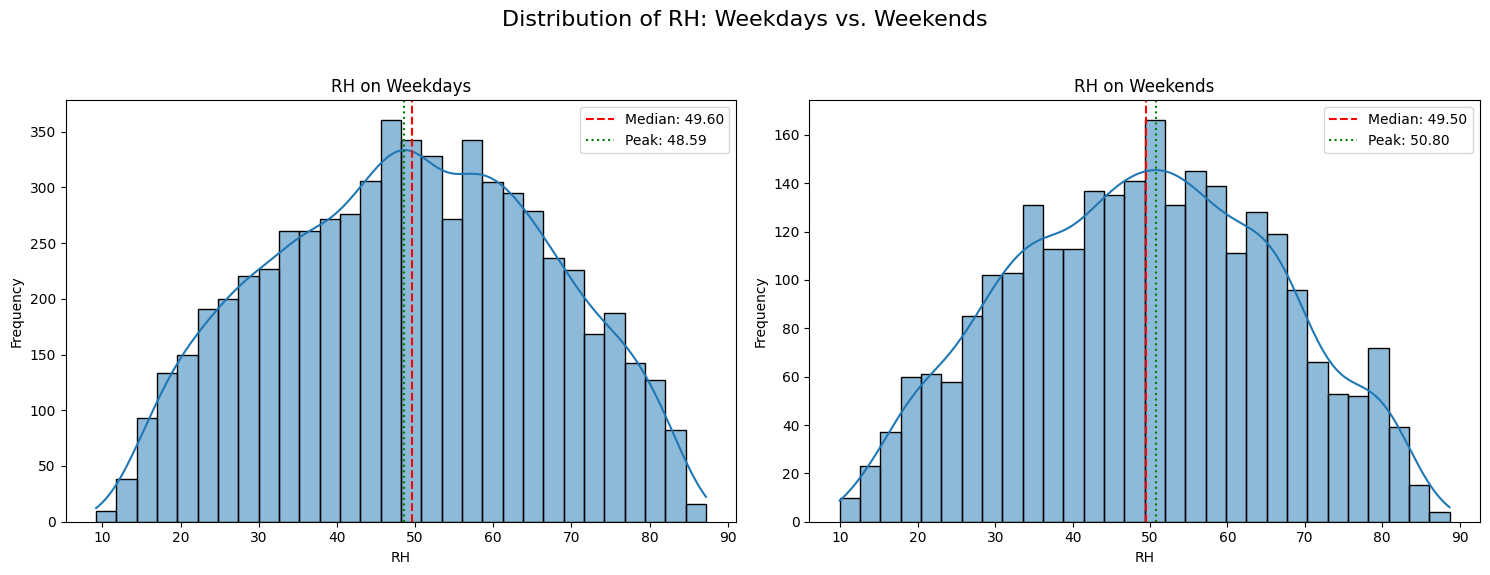

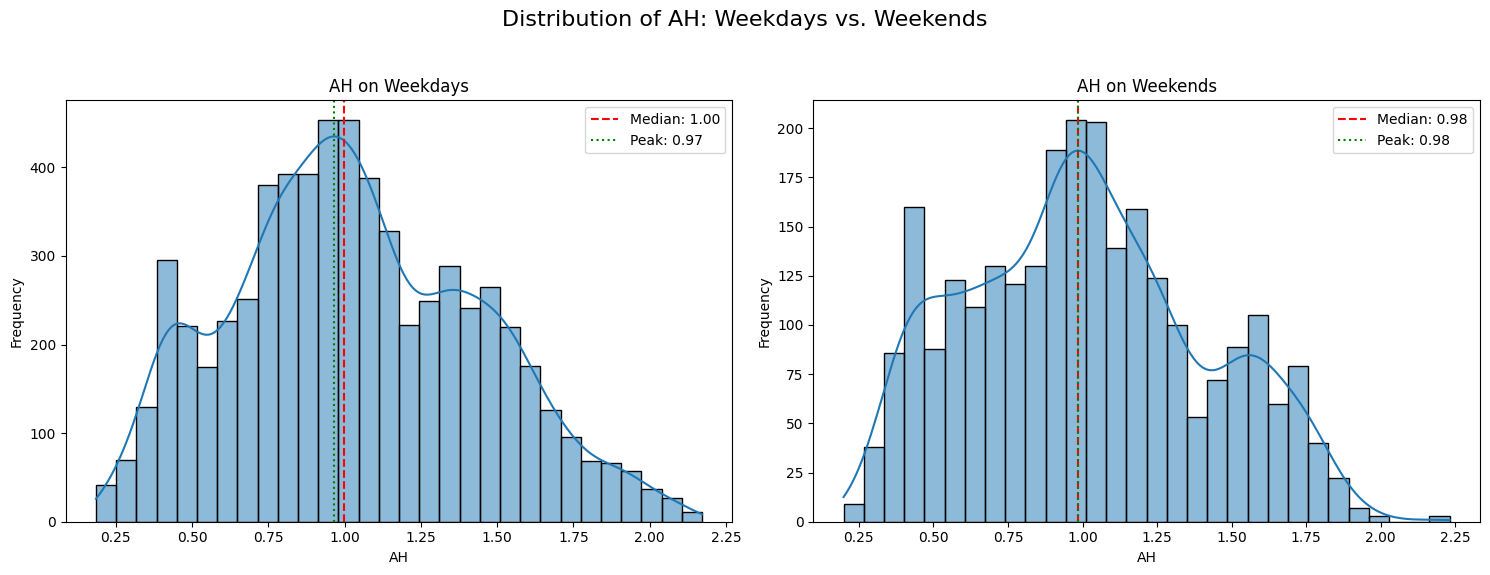

In [12]:
for feature in features:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Distribution of {feature}: Weekdays vs. Weekends', fontsize=16)

    data_weekdays = df_weekdays[feature].dropna()
    median_weekdays = data_weekdays.median()
    peak_weekdays = np.nan
    try:
        kde_weekdays = gaussian_kde(data_weekdays)
        x_weekdays = np.linspace(data_weekdays.min(), data_weekdays.max(), 500)
        y_weekdays = kde_weekdays(x_weekdays)
        peak_weekdays = x_weekdays[np.argmax(y_weekdays)]
    except np.linalg.LinAlgError:
        pass

    sns.histplot(data_weekdays, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'{feature} on Weekdays')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(median_weekdays, color='red', linestyle='--', label=f'Median: {median_weekdays:.2f}')
    if not np.isnan(peak_weekdays):
        axes[0].axvline(peak_weekdays, color='green', linestyle=':', label=f'Peak: {peak_weekdays:.2f}')
    axes[0].legend()

    data_weekends = df_weekends[feature].dropna()
    median_weekends = data_weekends.median()
    peak_weekends = np.nan
    try:
        kde_weekends = gaussian_kde(data_weekends)
        x_weekends = np.linspace(data_weekends.min(), data_weekends.max(), 500)
        y_weekends = kde_weekends(x_weekends)
        peak_weekends = x_weekends[np.argmax(y_weekends)]
    except np.linalg.LinAlgError:
        pass

    sns.histplot(data_weekends, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f'{feature} on Weekends')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(median_weekends, color='red', linestyle='--', label=f'Median: {median_weekends:.2f}')
    if not np.isnan(peak_weekends):
        axes[1].axvline(peak_weekends, color='green', linestyle=':', label=f'Peak: {peak_weekends:.2f}')
    axes[1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Statistical tests to quantify weekday-weekend distribution differences.

In [13]:
results = {}
alpha = 0.05

for feature in features:
    data_weekdays = df_weekdays[feature].dropna()
    data_weekends = df_weekends[feature].dropna()

    if len(data_weekdays) < 2 or len(data_weekends) < 2:
        print(f"Skipping {feature}: Not enough data for comparison (weekdays: {len(data_weekdays)}, weekends: {len(data_weekends)})")
        continue

    mw_statistic, mw_p_value = mannwhitneyu(data_weekdays, data_weekends, alternative='two-sided')
    ks_statistic, ks_p_value = ks_2samp(data_weekdays, data_weekends)

    results[feature] = {
        'Mann-Whitney U P-value': mw_p_value,
        'Mann-Whitney U Significant': mw_p_value < alpha,
        'K-S P-value': ks_p_value,
        'K-S Significant': ks_p_value < alpha
    }

print("Statistical Test Results:")
for feature, res in results.items():
    print(f"\nFeature: {feature}")
    print(f"  Mann-Whitney U Test P-value: {res['Mann-Whitney U P-value']:.4g} (Significant: {res['Mann-Whitney U Significant']})")
    print(f"  K-S Test P-value: {res['K-S P-value']:.4g} (Significant: {res['K-S Significant']})")

Statistical Test Results:

Feature: CO(GT)
  Mann-Whitney U Test P-value: 5.375e-80 (Significant: True)
  K-S Test P-value: 4.86e-68 (Significant: True)

Feature: PT08.S1(CO)
  Mann-Whitney U Test P-value: 6.49e-36 (Significant: True)
  K-S Test P-value: 2.951e-27 (Significant: True)

Feature: C6H6(GT)
  Mann-Whitney U Test P-value: 8.576e-96 (Significant: True)
  K-S Test P-value: 1.942e-108 (Significant: True)

Feature: PT08.S2(NMHC)
  Mann-Whitney U Test P-value: 9.607e-96 (Significant: True)
  K-S Test P-value: 1.115e-108 (Significant: True)

Feature: NMHC(GT)
  Mann-Whitney U Test P-value: 1.949e-07 (Significant: True)
  K-S Test P-value: 3.724e-10 (Significant: True)

Feature: NOx(GT)
  Mann-Whitney U Test P-value: 8.671e-47 (Significant: True)
  K-S Test P-value: 1.282e-32 (Significant: True)

Feature: PT08.S3(NOx)
  Mann-Whitney U Test P-value: 4.363e-61 (Significant: True)
  K-S Test P-value: 4.467e-55 (Significant: True)

Feature: NO2(GT)
  Mann-Whitney U Test P-value: 2.858e

## Compare data by season

Group observations into meteorological seasons to see broad shifts.

Label each record with a season and review counts.

In [14]:
conditions = [
    (df.index.month == 12) | (df.index.month == 1) | (df.index.month == 2),
    (df.index.month >= 3) & (df.index.month <= 5),
    (df.index.month >= 6) & (df.index.month <= 8),
    (df.index.month >= 9) & (df.index.month <= 11)
]

choices = ['Winter', 'Spring', 'Summer', 'Autumn']

df['season'] = np.select(conditions, choices, default='Unknown')

display(df[['month', 'season']].head())
print('Season counts:')
display(df['season'].value_counts())

,month,season
datetime,,
2004-03-10 18:00:00,3,Spring
2004-03-10 19:00:00,3,Spring
2004-03-10 20:00:00,3,Spring
2004-03-10 21:00:00,3,Spring
2004-03-10 22:00:00,3,Spring


Season counts:


season
Spring    2805
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

Plot feature distributions by season.

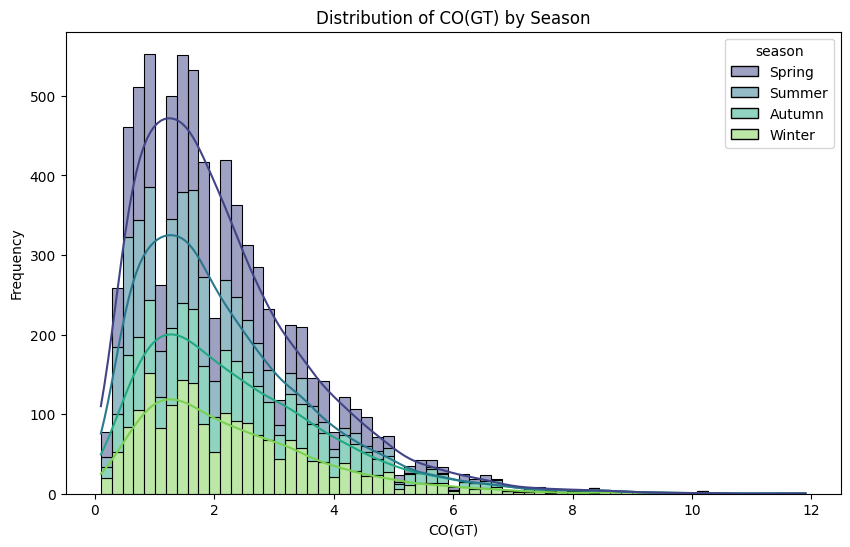

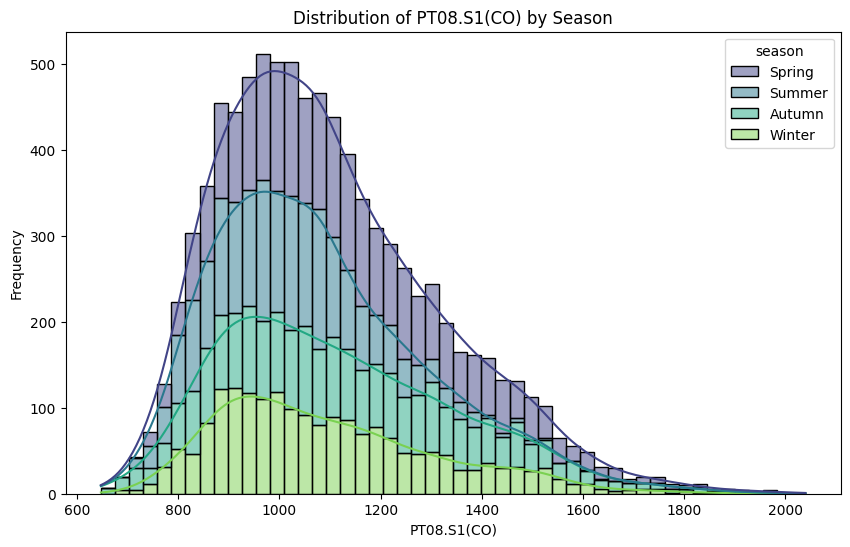

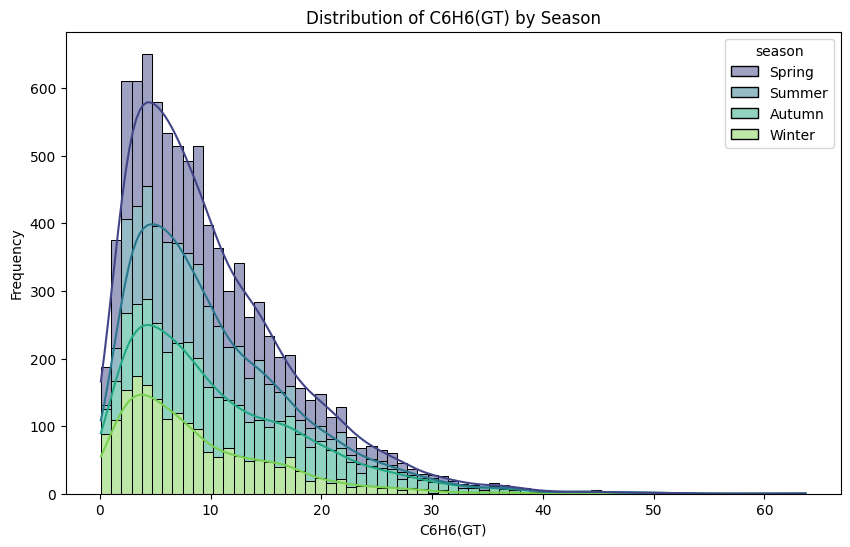

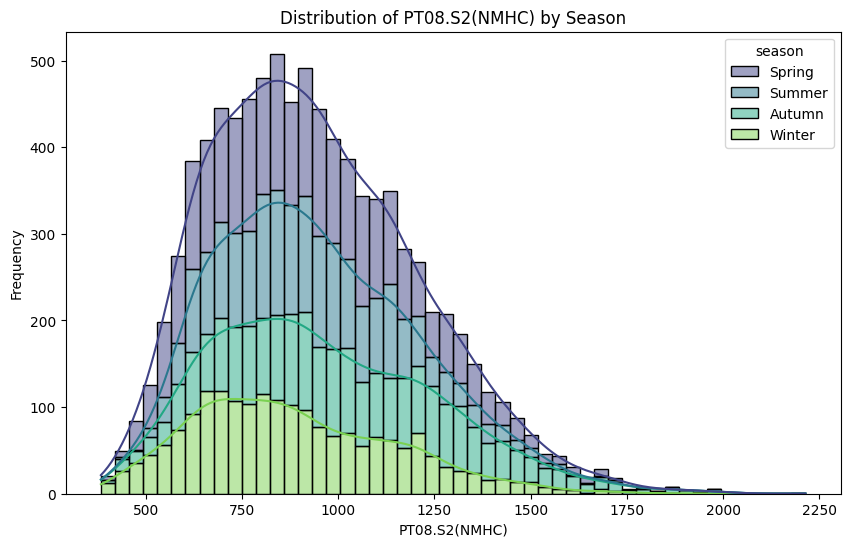

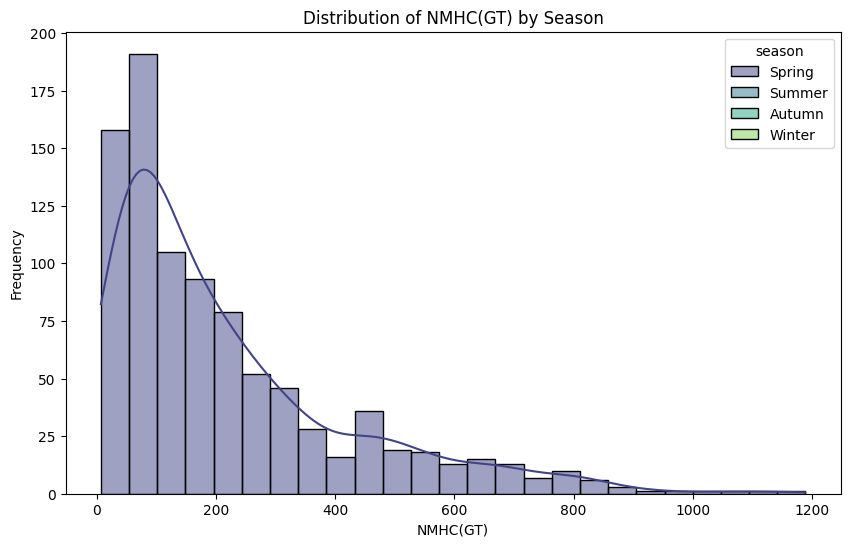

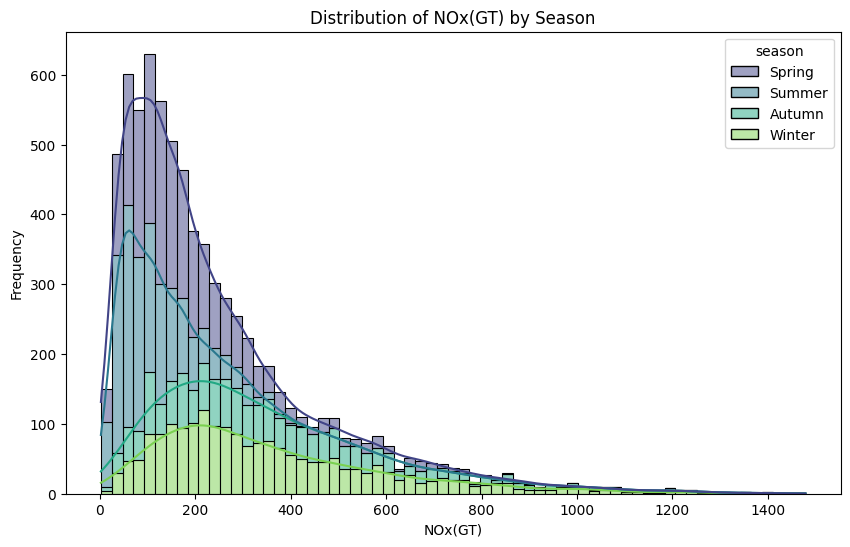

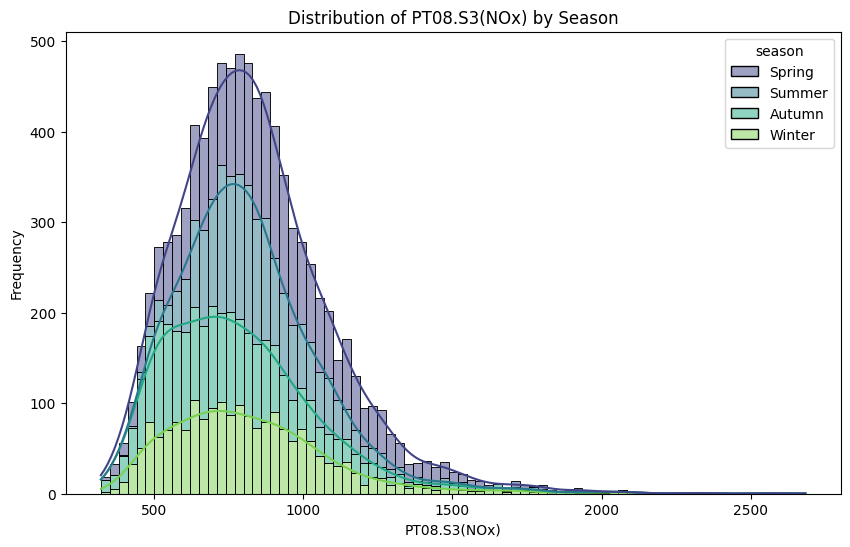

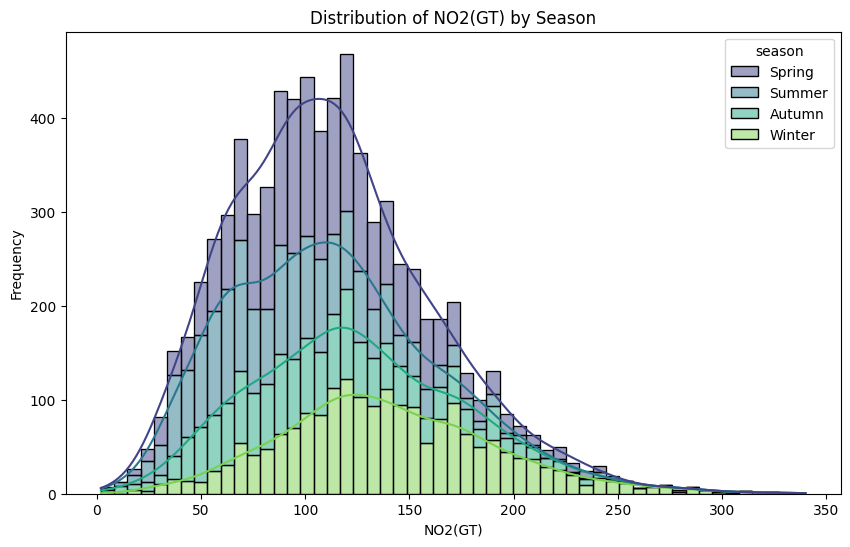

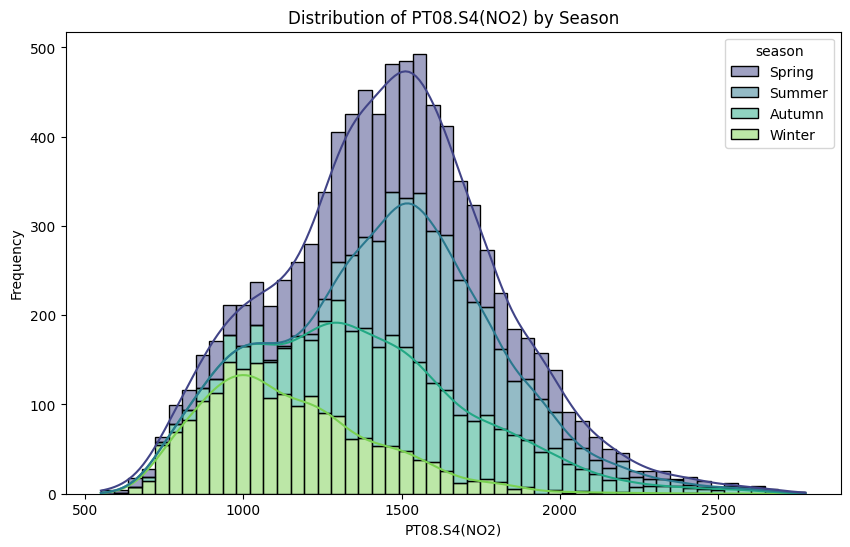

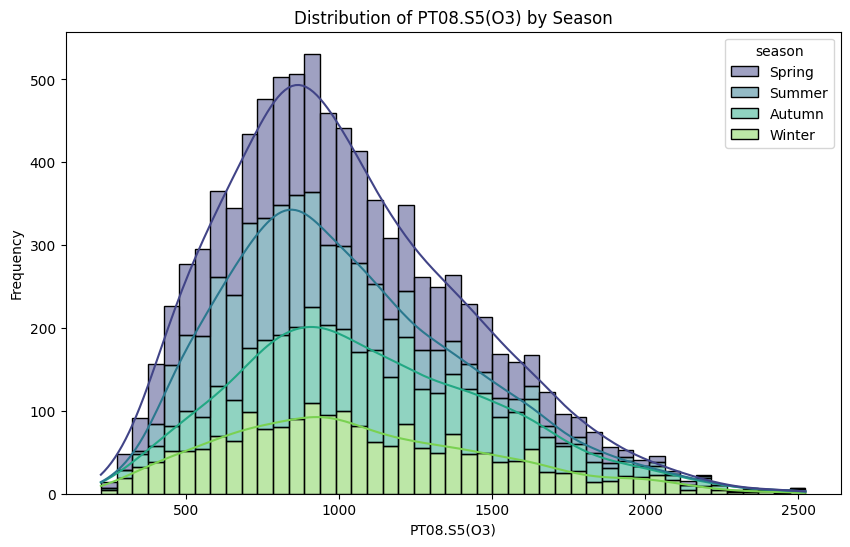

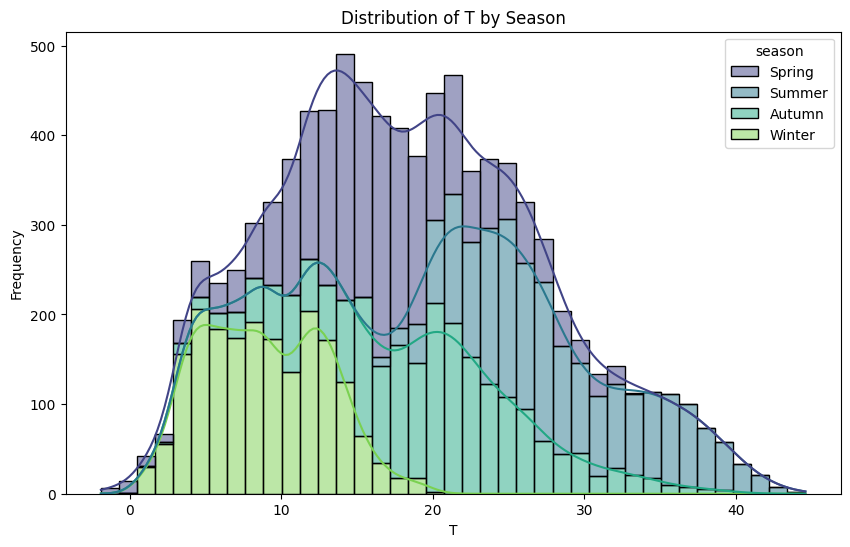

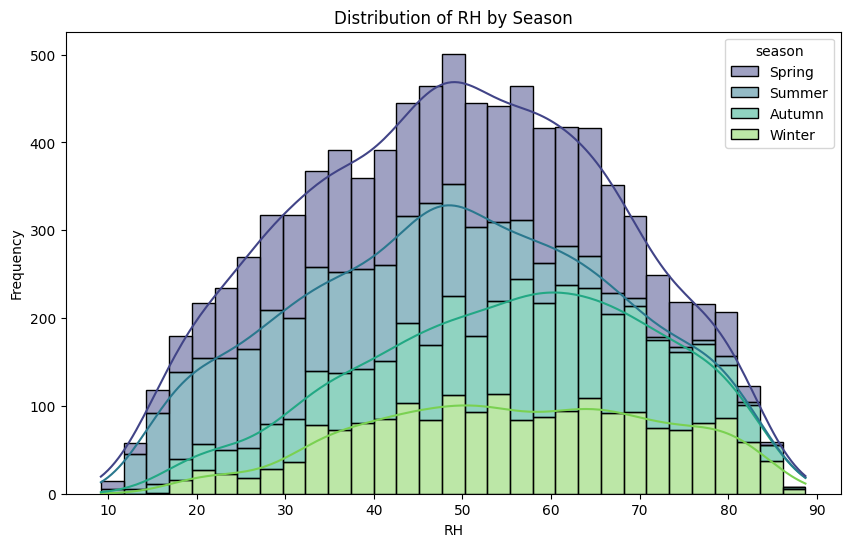

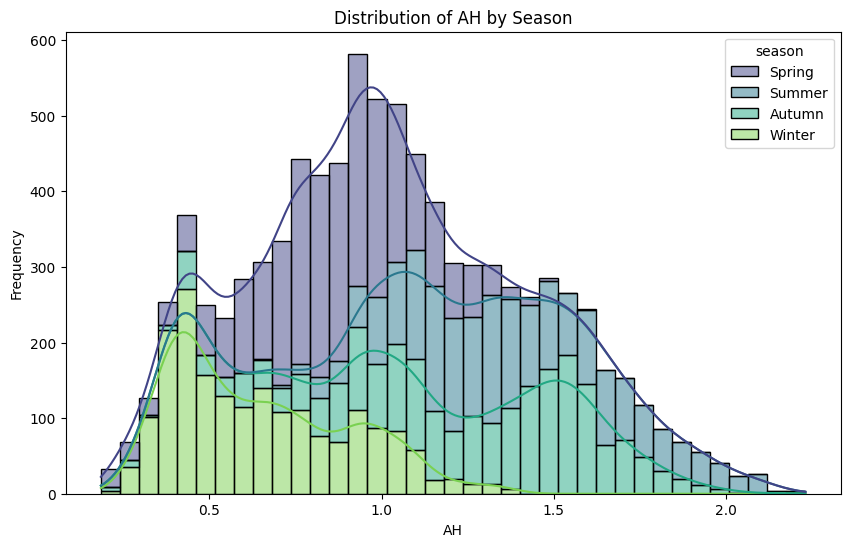

In [15]:
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df,
        x=feature,
        hue='season',
        kde=True,
        palette='viridis',
        multiple='stack'
    )
    plt.title(f'Distribution of {feature} by Season')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

## Analyze correlations between parameters

Inspect pairwise correlations, including season encoded numerically.

Compute correlation matrix with season mapped to numeric codes.

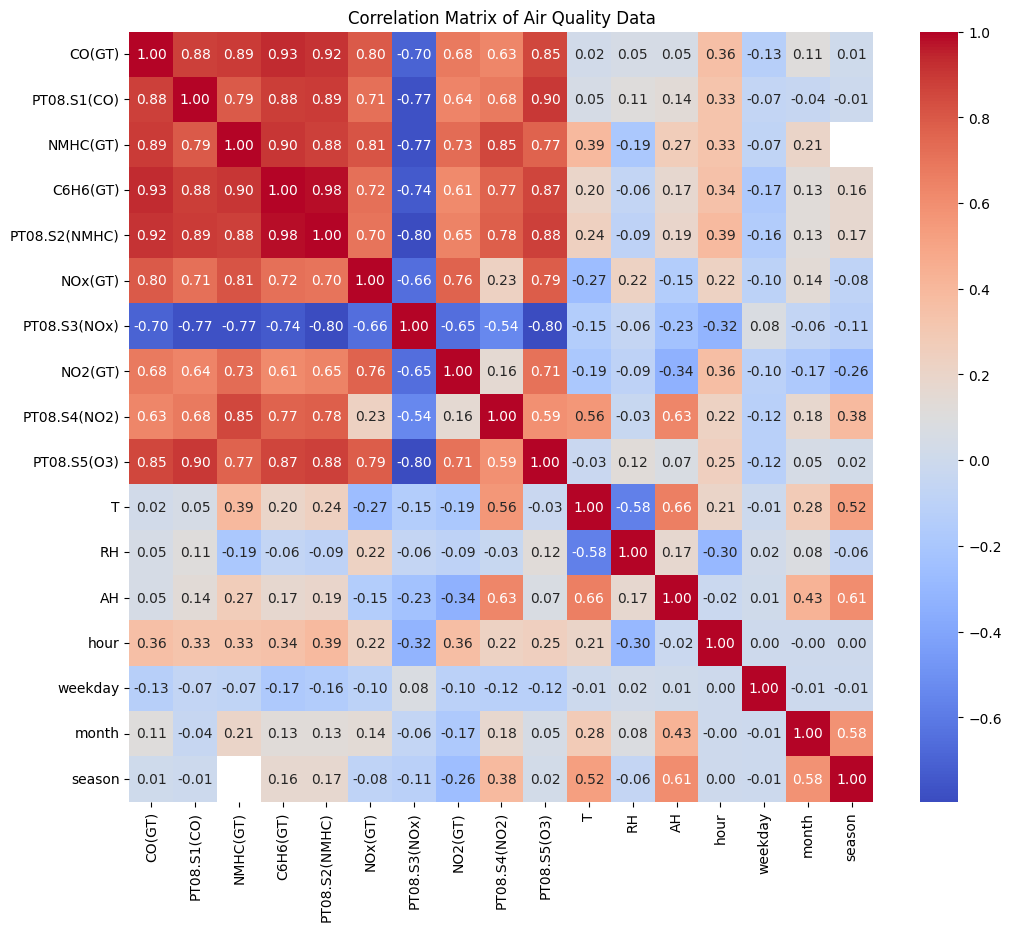

In [16]:
season_mapping = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3, 'Unknown': np.nan}
corr_df = df.copy()
corr_df['season'] = corr_df['season'].map(season_mapping)
correlation_matrix = corr_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Air Quality Data')
plt.show()

## Analyse relationships between meteorological and chemical variables

Explore how temperature and humidity relate to pollutant concentrations.

Scatter plots to show associations between weather variables and pollutants.

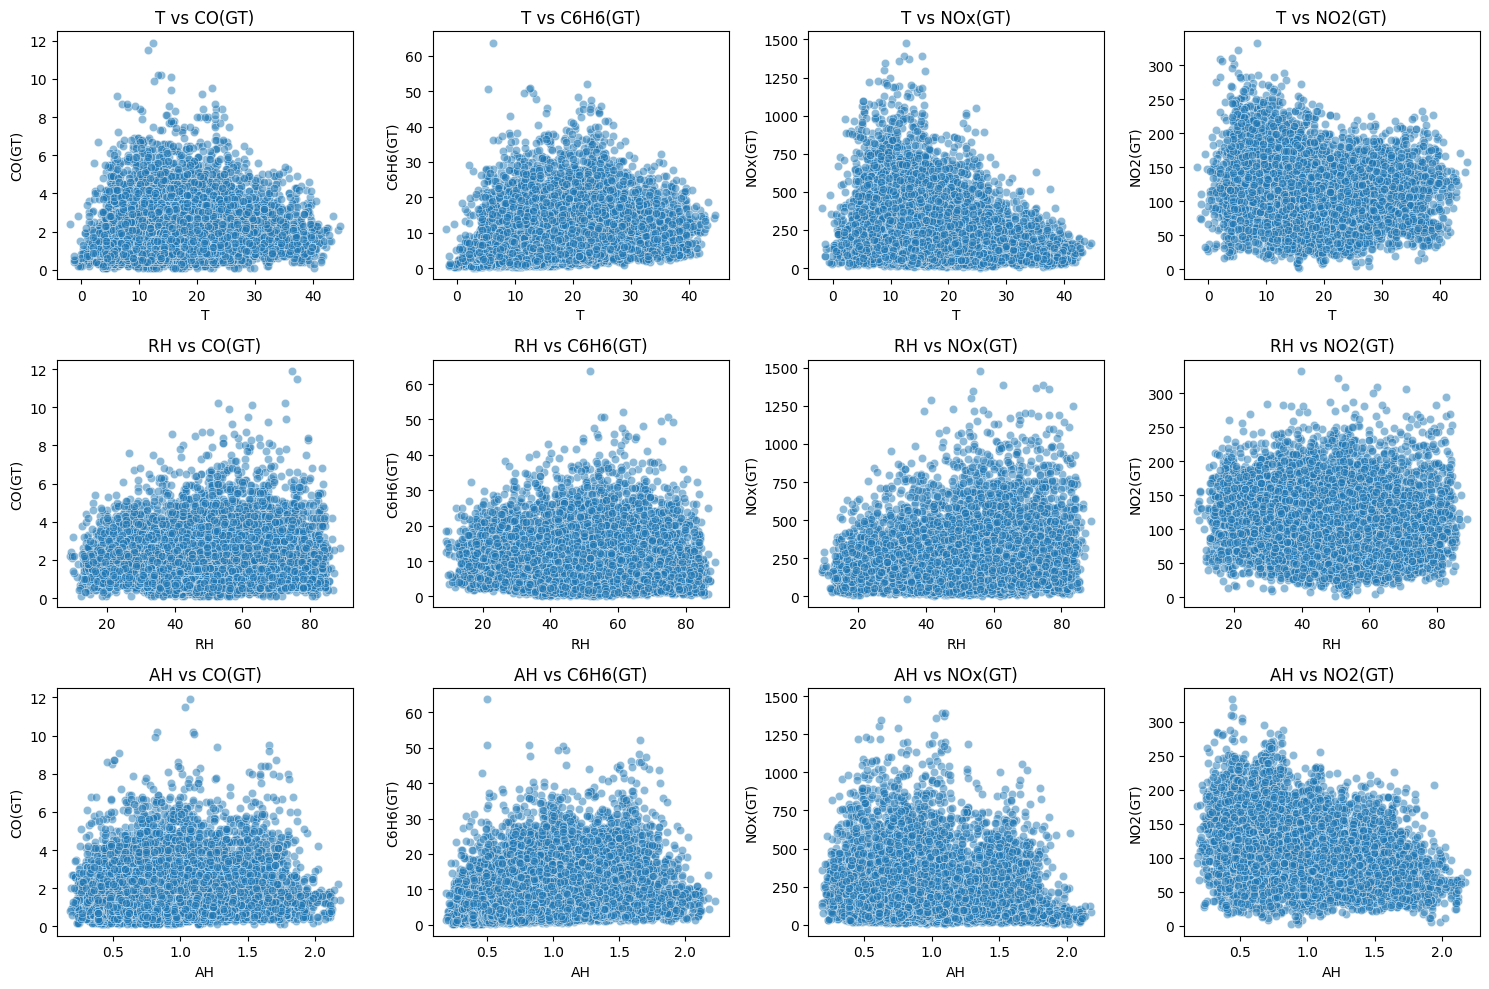

In [17]:
meteorological_vars = ['T', 'RH', 'AH']
chemical_vars = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

plt.figure(figsize=(15, 10))
for i, met_var in enumerate(meteorological_vars):
    for j, chem_var in enumerate(chemical_vars):
        plt.subplot(len(meteorological_vars), len(chemical_vars), i * len(chemical_vars) + j + 1)
        sns.scatterplot(x=df[met_var], y=df[chem_var], alpha=0.5)
        plt.title(f'{met_var} vs {chem_var}')
        plt.xlabel(met_var)
        plt.ylabel(chem_var)

plt.tight_layout()
plt.show()

Pearson correlations between meteorological and chemical variables.

In [18]:
correlation_results = {}

for met_var in meteorological_vars:
    for chem_var in chemical_vars:
        temp_df = df[[met_var, chem_var]].dropna()
        correlation, p_value = pearsonr(temp_df[met_var], temp_df[chem_var])
        correlation_results[f'{met_var} vs {chem_var}'] = {
            'correlation': correlation,
            'p_value': p_value
        }

print('Pearson Correlation Results between Meteorological and Chemical Variables:')
for pair, results in correlation_results.items():
    print(f"  {pair}: Correlation = {results['correlation']:.4f}, P-value = {results['p_value']:.4g}")

Pearson Correlation Results between Meteorological and Chemical Variables:
  T vs CO(GT): Correlation = 0.0221, P-value = 0.05815
  T vs C6H6(GT): Correlation = 0.1990, P-value = 6.166e-81
  T vs NOx(GT): Correlation = -0.2697, P-value = 1.992e-123
  T vs NO2(GT): Correlation = -0.1865, P-value = 7.201e-59
  RH vs CO(GT): Correlation = 0.0489, P-value = 2.771e-05
  RH vs C6H6(GT): Correlation = -0.0617, P-value = 4.817e-09
  RH vs NOx(GT): Correlation = 0.2210, P-value = 1.585e-82
  RH vs NO2(GT): Correlation = -0.0918, P-value = 2.679e-15
  AH vs CO(GT): Correlation = 0.0486, P-value = 3.143e-05
  AH vs C6H6(GT): Correlation = 0.1680, P-value = 6.812e-58
  AH vs NOx(GT): Correlation = -0.1493, P-value = 3.848e-38
  AH vs NO2(GT): Correlation = -0.3350, P-value = 2.338e-193


## Identify data quality issues

Check for outliers and other anomalies.

Box plots to flag potential outliers and a statistical summary for each feature.

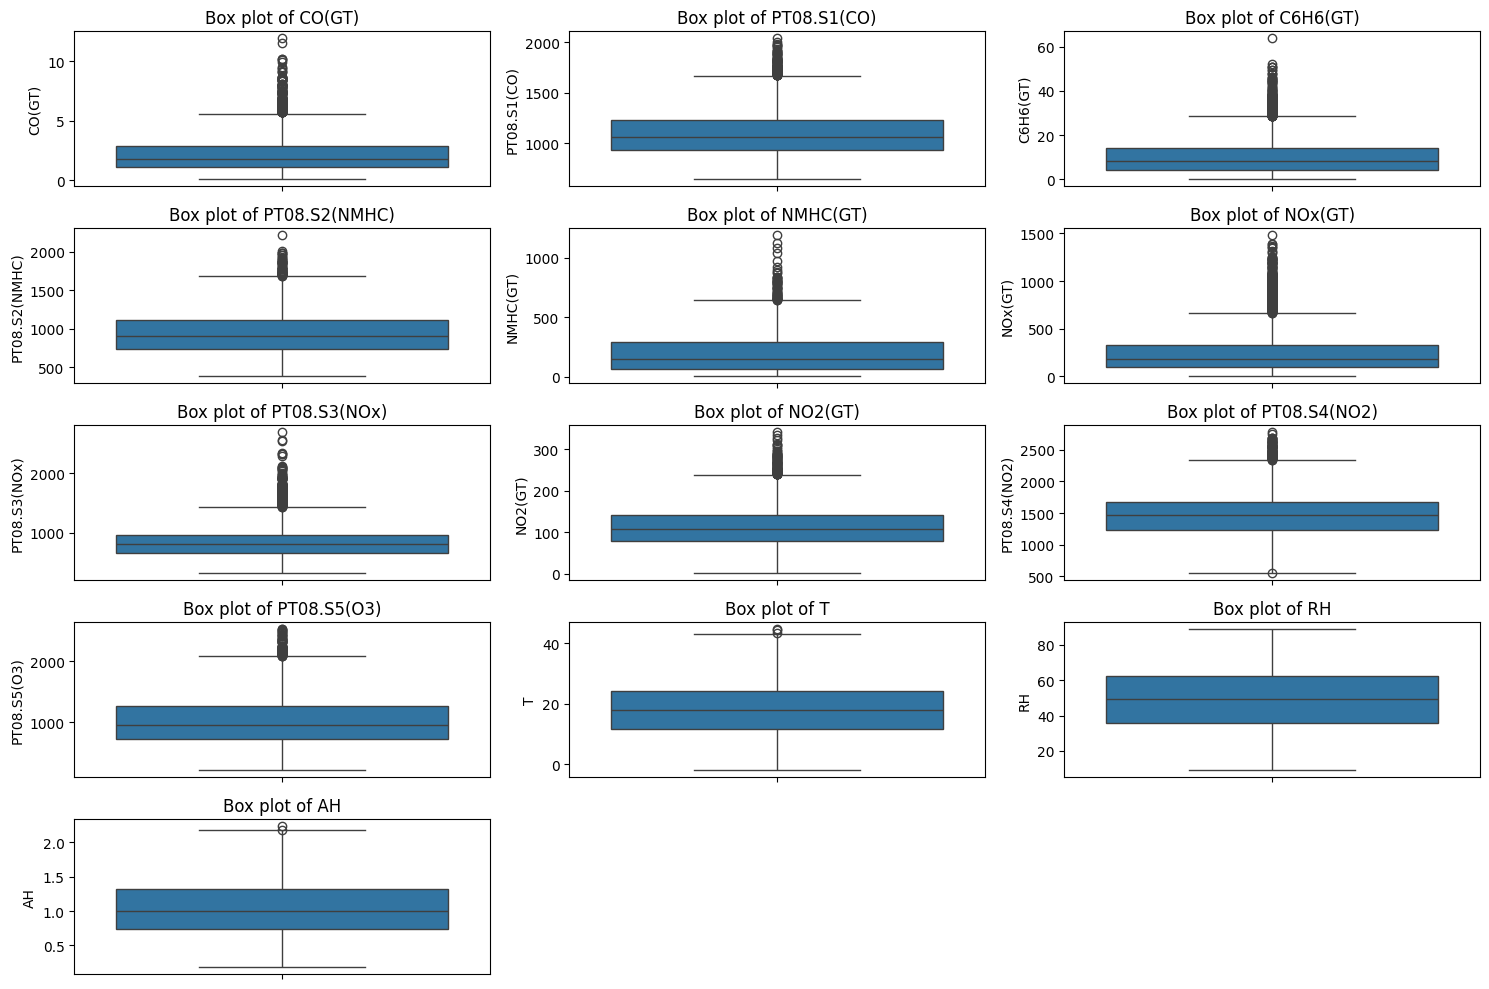


Statistics:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour,weekday,month
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357.000000,9357.000000,9357.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,11.498557,3.009939,6.310356
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,6.923182,2.000323,3.438160
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.000000,0.000000,1.000000
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,5.000000,1.000000,3.000000
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,11.000000,3.000000,6.000000
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,18.000000,5.000000,9.000000
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,23.000000,6.000000,12.000000


In [19]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(len(features) // 3 + 1, 3, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(f'Box plot of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

print("\nStatistics:")
display(df.describe())